# Chladni cymatics — mode schemes, D4 symmetry, sand grains

`biotuner.harmonic_geometry.media.eigenmode.RigidPlate` now exposes four
chord→mode schemes, two D4 symmetry options, and a Gaussian-of-zero-
crossing density transform — together they reproduce the iconic
sand-on-square-plate Chladni patterns from integer-ratio chord inputs.
This notebook walks every option, then animates the morph between
chords.

The cymatics schemes treat each chord ratio as an **integer
wavenumber** `(m, n)` on the plate. Two routes to feed them:

- pass a small-integer chord list directly (e.g. ``Major = [4, 5, 6]``,
  ``Dom7 = [4, 5, 6, 7]``) — the natural just-intonation form,
- or pass a ``HarmonicInput`` of ``Fraction`` ratios and let
  ``chord_to_int_modes`` (LCM of denominators) recover an integer form.

The first route is preferred for "clean" patterns: ``Dim7`` as
``[5, 6, 7, 9]`` reads as a clean cross-lattice, while the same chord
expressed as ``[1, 6/5, 7/5, 12/7]`` blows up under LCM to
``[35, 42, 49, 60]`` and tiles the plate with sub-pixel detail. The
new ``max_mode`` cap (section 6) scales such cases back into a
visible range without losing the chord's ratio structure.


In [1]:
import warnings
import os
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from biotuner.harmonic_geometry import HarmonicInput, plotting
from biotuner.harmonic_geometry.media import RigidPlate, Granular, Pipeline
from biotuner.harmonic_geometry.media.eigenmode.rigid_plate import (
    chord_to_int_modes,
    chladni_field_pairwise,
    chladni_field_triple_antisymmetric,
    chladni_nodal_density,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

# Small-integer just-intoned chord representations. These are the natural
# wavenumber form for the cymatics schemes — pass them straight to
# chladni_field_pairwise / chladni_field_triple_antisymmetric.
CHORDS_INT = {
    "Major": [4, 5, 6],
    "Sus4":  [6, 8, 9],
    "Dom7":  [4, 5, 6, 7],
    "Dim7":  [5, 6, 7, 9],
}

# Same chords as HarmonicInput / Fraction ratios — for the LCM-conversion
# section below and for routing through the RigidPlate medium.
CHORDS_HI = {
    "Major": HarmonicInput(ratios=[Fraction(r, CHORDS_INT["Major"][0])
                                    for r in CHORDS_INT["Major"]]),
    "Sus4":  HarmonicInput(ratios=[Fraction(r, CHORDS_INT["Sus4"][0])
                                    for r in CHORDS_INT["Sus4"]]),
    "Dom7":  HarmonicInput(ratios=[Fraction(r, CHORDS_INT["Dom7"][0])
                                    for r in CHORDS_INT["Dom7"]]),
    "Dim7":  HarmonicInput(ratios=[Fraction(r, CHORDS_INT["Dim7"][0])
                                    for r in CHORDS_INT["Dim7"]]),
}


## 1. Integer chord ratios — lossless, and when to cap

For chords already in just-intonation small-integer form
(``Major = [4, 5, 6]``), ``chord_to_int_modes`` round-trips them
unchanged. For chords in 12-TET-flavoured ``Fraction`` form the
LCM-of-denominators conversion can blow up — that is the maths of the
rationals, not a bug — and the pattern becomes a fine-grained lattice
that reads as "dots". The new ``max_mode`` cap rescues that case by
scaling all wavenumbers proportionally down to a visible range
(ratios are preserved):


In [2]:
from biotuner.harmonic_geometry.media.eigenmode.rigid_plate import _cap_modes

for name, c in CHORDS_HI.items():
    int_form = chord_to_int_modes(c.to_ratios())
    capped   = _cap_modes(int_form, 12)
    print(f"  {name:6s}  Fraction = {[str(r) for r in c.to_ratios()]}")
    print(f"          → int_form = {int_form}    capped@12 = {capped}")


## 2. The four `mode_scheme` options

All four schemes are eigenmode-family operators on a rectangular plate.
The classical ``per_ratio`` scheme assigns one Stern-Brocot mode pair to
each ratio. The cymatics schemes sum modes over **pairs** (or
**triples**) of ratios — emphasising the harmonic *relationships* in
the chord rather than the individual partials.

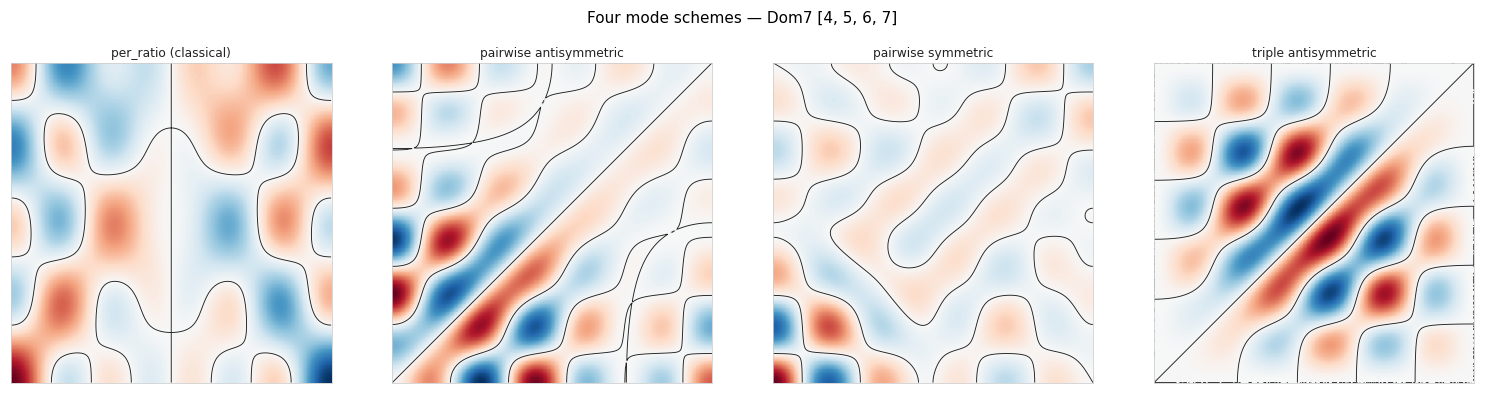

In [3]:
dom7_int = CHORDS_INT["Dom7"]
dom7_hi  = CHORDS_HI["Dom7"]

# per_ratio routes through HarmonicInput (Stern-Brocot mapping per ratio);
# the cymatics routines accept the integer chord list directly.
g_pr = RigidPlate(mode_scheme="per_ratio", resolution=400)(dom7_hi)
g_pa = chladni_field_pairwise(dom7_int, antisymmetric=True,  resolution=400)
g_ps = chladni_field_pairwise(dom7_int, antisymmetric=False, resolution=400)
g_tr = chladni_field_triple_antisymmetric(dom7_int, resolution=400)

plotting.gallery(
    [g_pr, g_pa, g_ps, g_tr], n_cols=4,
    titles=["per_ratio (classical)",
            "pairwise antisymmetric",
            "pairwise symmetric",
            "triple antisymmetric"],
    suptitle="Four mode schemes — Dom7 [4, 5, 6, 7]",
    fig_width=14.0,
);


## 3. D4 symmetrisation — `none` / `d4_max` / `d4_sum`

The dihedral group D4 has 8 elements (4 rotations × 2 reflections).

- **``none``** — leave the field as-is.
- **``d4_max``** — element-wise *maximum* over the orbit. Non-linear
  symmetriser that preserves bright features → the crystalline lattice
  look (the original cymatics demo used this).
- **``d4_sum``** — orbit *average*. Linear, smoother; enforces strict
  D4 symmetry without amplifying any one orientation.


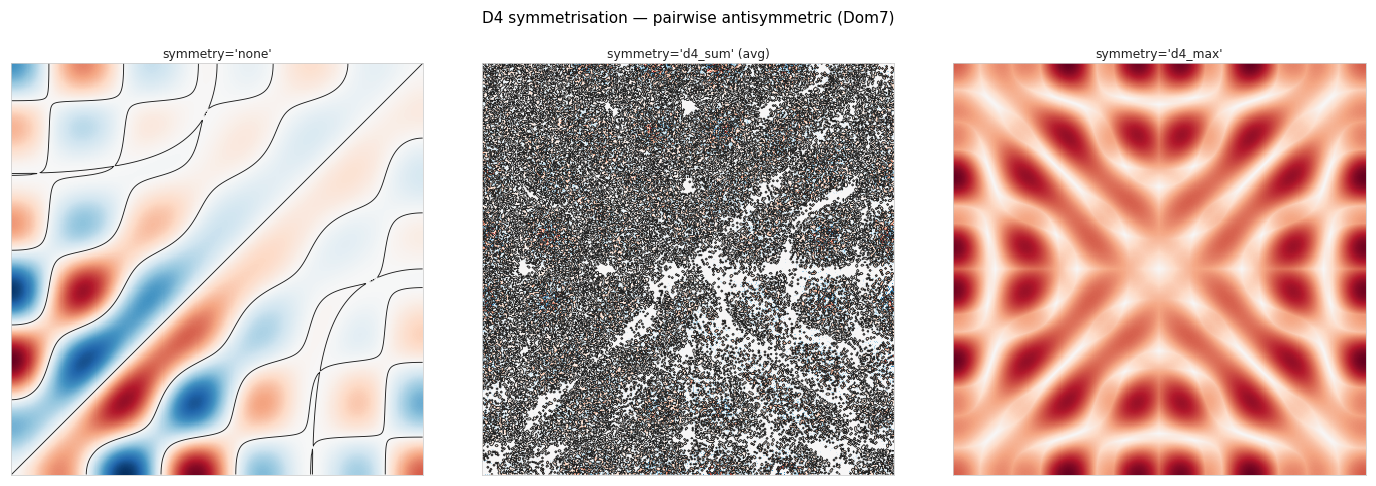

In [4]:
geoms = [
    chladni_field_pairwise(dom7_int, antisymmetric=True, symmetry=s, resolution=400)
    for s in ("none", "d4_sum", "d4_max")
]
plotting.gallery(
    geoms, n_cols=3,
    titles=["symmetry='none'", "symmetry='d4_sum' (avg)", "symmetry='d4_max'"],
    suptitle="D4 symmetrisation — pairwise antisymmetric (Dom7)",
    fig_width=13.0,
);


## 4. Nodal density — `exp(-w² / σ²)`

The classical Chladni experiment shows sand **collecting on the nodal
lines** (where the plate displacement is zero). Mathematically captured
by the Gaussian-of-zero-crossing transform:

$$d(x, y) = \exp\!\left(-\frac{w(x, y)^2}{\sigma^2}\right)$$

`σ` controls the stripe width — small `σ` gives razor-thin nodal lines,
large `σ` gives wider soft bands.


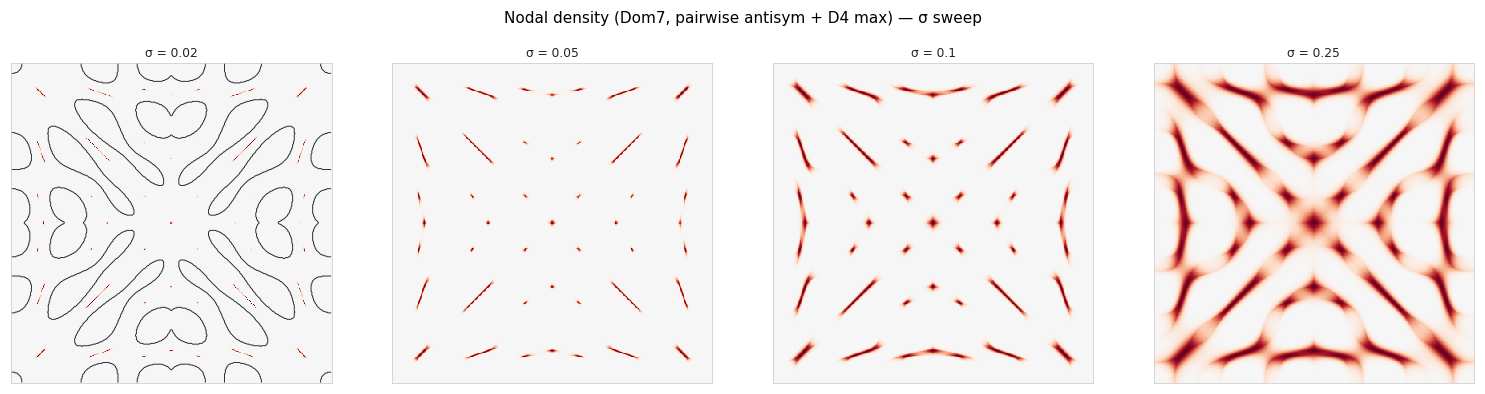

In [5]:
field = chladni_field_pairwise(
    dom7_int, antisymmetric=True, symmetry="d4_max", resolution=400,
)
sigmas = [0.02, 0.05, 0.10, 0.25]
geoms = [chladni_nodal_density(field, sigma=s) for s in sigmas]
plotting.gallery(
    geoms, n_cols=4,
    titles=[f"σ = {s}" for s in sigmas],
    suptitle="Nodal density (Dom7, pairwise antisym + D4 max) — σ sweep",
    fig_width=14.0,
);


### Antinodal density

``chladni_nodal_density(..., mode="antinodal")`` gives the complement —
sand on the antinodes instead of the nodes. A coral / fingerprint
texture rather than the iconic lattice.

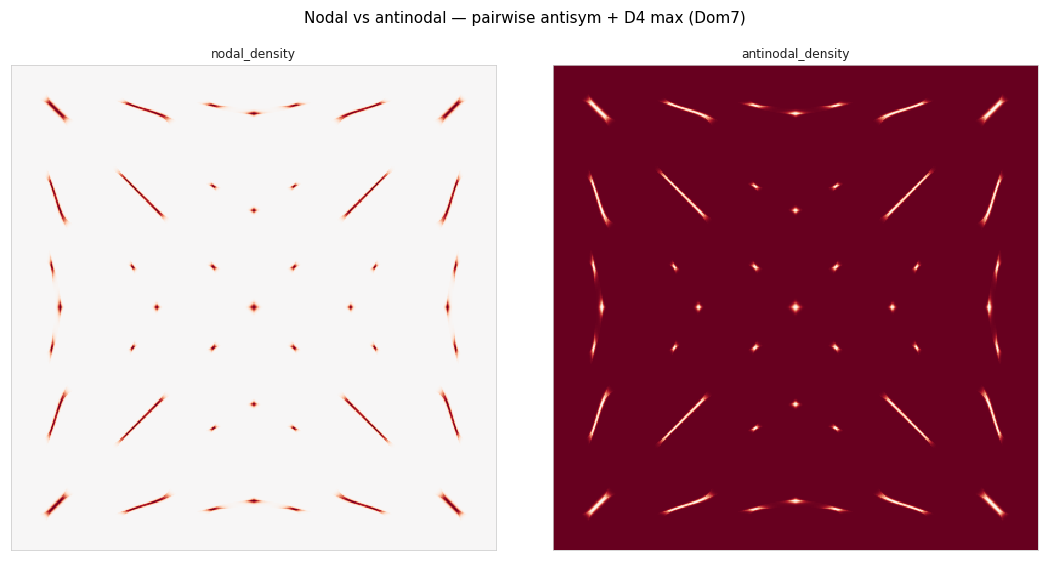

In [6]:
plotting.gallery(
    [chladni_nodal_density(field, sigma=0.05, mode="nodal"),
     chladni_nodal_density(field, sigma=0.05, mode="antinodal")],
    n_cols=2,
    titles=["nodal_density", "antinodal_density"],
    suptitle="Nodal vs antinodal — pairwise antisym + D4 max (Dom7)",
    fig_width=10.0,
);


## 5. Chord-fingerprint gallery — pairwise antisym + D4 max + nodal density

The full cymatics stack gives a distinctive fingerprint per chord:

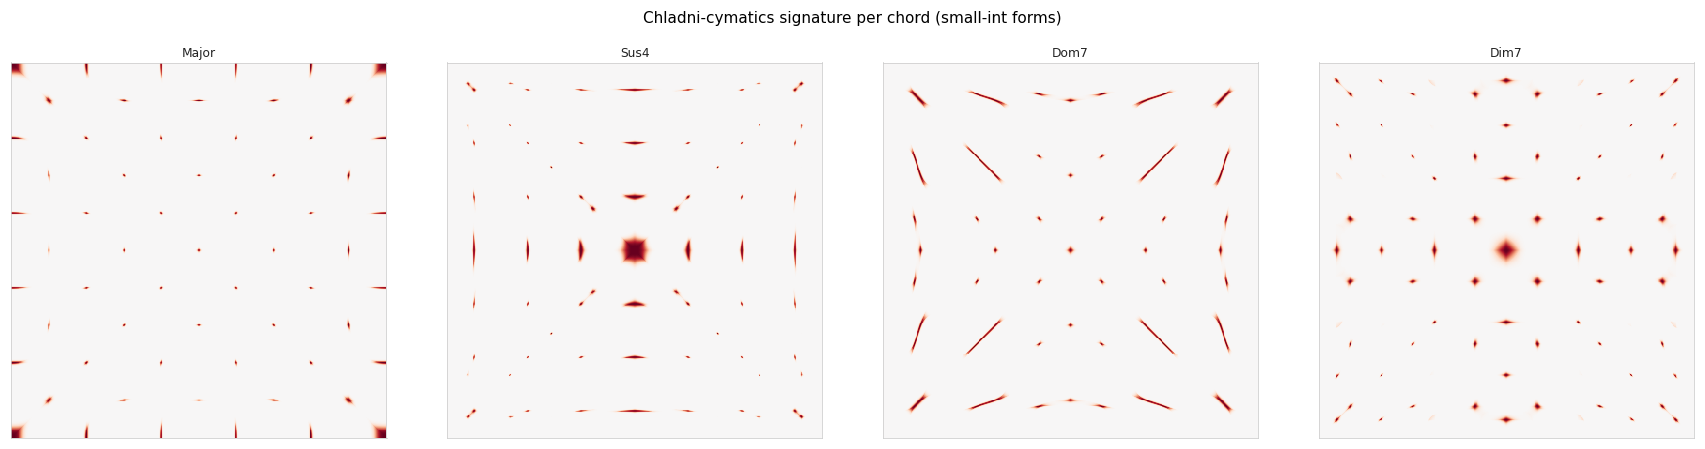

In [7]:
sigma = 0.05
geoms = [
    chladni_nodal_density(
        chladni_field_pairwise(
            CHORDS_INT[name], antisymmetric=True, symmetry="d4_max",
            resolution=400,
        ),
        sigma=sigma,
    )
    for name in CHORDS_INT
]
plotting.gallery(
    geoms, n_cols=4, titles=list(CHORDS_INT.keys()),
    suptitle="Chladni-cymatics signature per chord (small-int forms)",
    fig_width=16.0,
);


## 6. Sand-grain particle rendering

The most photographic look: instead of an ``imshow`` of the density,
stochastically sample N particles from it and draw small white dots on
black. ``Granular(nodal_emphasis=True, ...)`` bypasses its Boltzmann
formulation and uses ``exp(-w²/σ²)`` directly on the incoming field.
Compose any field-producing medium with
``Granular(output_mode="particles", nodal_emphasis=True)``.

Visible-feature size depends on the chord's wavenumber range — small
integer chords (max ~10) give bold flowing curves; let high-LCM chords
through unscaled and they crumble into the lattice. With small-int
forms, no cap is needed and the patterns read clearly:


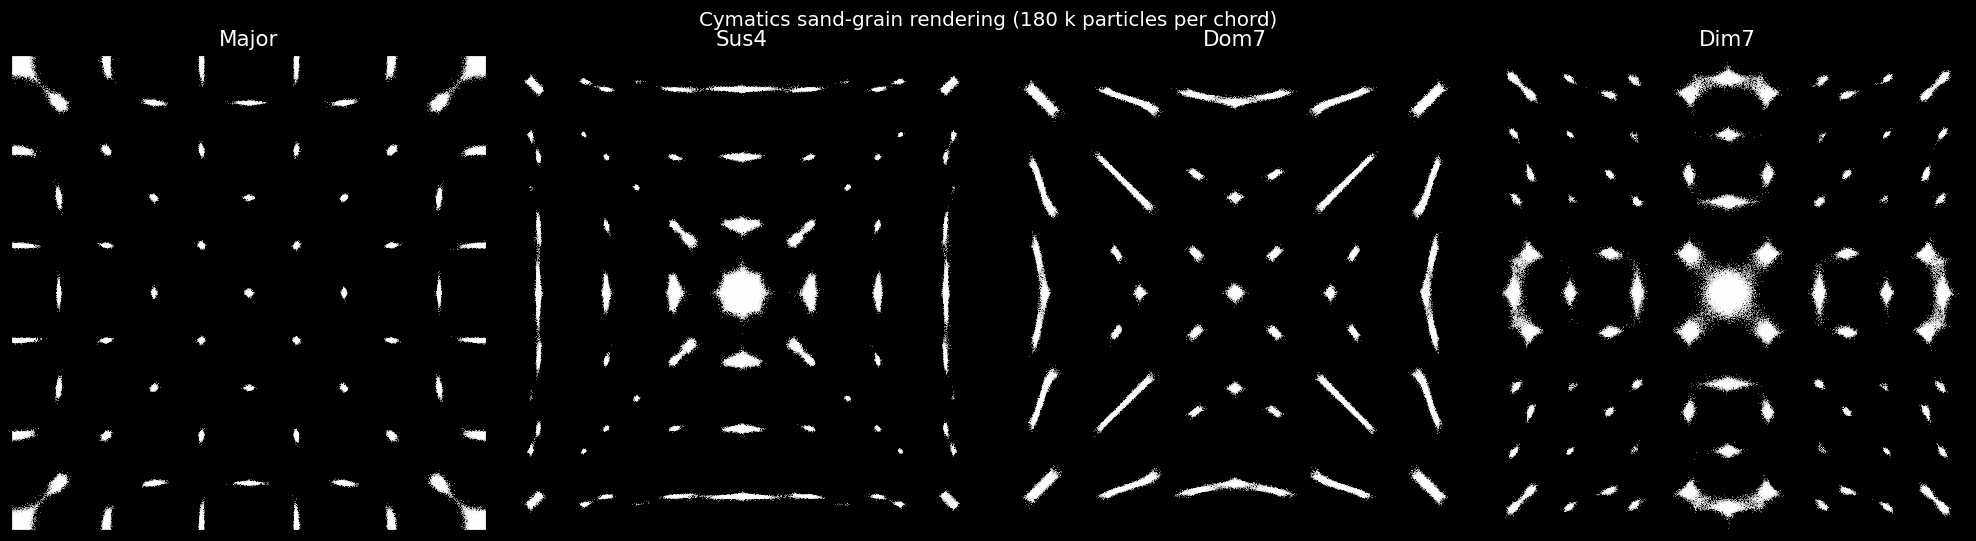

In [8]:
def sand_for(chord_int, n_particles=180_000, sigma=0.06):
    field = chladni_field_pairwise(
        chord_int, antisymmetric=True, symmetry="d4_max", resolution=400,
    )
    return Granular(
        output_mode="particles", nodal_emphasis=True, sigma=sigma,
        n_particles=n_particles, seed=0,
    ).respond(field)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.7), facecolor="black")
for ax, (name, chord_int) in zip(axes, CHORDS_INT.items()):
    pts = sand_for(chord_int).coordinates
    ax.set_facecolor("black")
    ax.scatter(pts[:, 0], pts[:, 1], s=0.5, c="white", alpha=0.45,
               linewidths=0)
    ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(name, color="white", fontsize=14)
fig.suptitle("Cymatics sand-grain rendering (180 k particles per chord)",
             color="white", fontsize=13, y=1.02)
fig.tight_layout(pad=0.5);


### `max_mode` rescues high-LCM chords

If you pass ``Dim7`` as its 12-TET-flavoured ``Fraction`` form
(``[1, 6/5, 7/5, 12/7]``), ``chord_to_int_modes`` blows it up to
``[35, 42, 49, 60]`` — sub-pixel lattice. ``max_mode=...`` scales
proportionally:

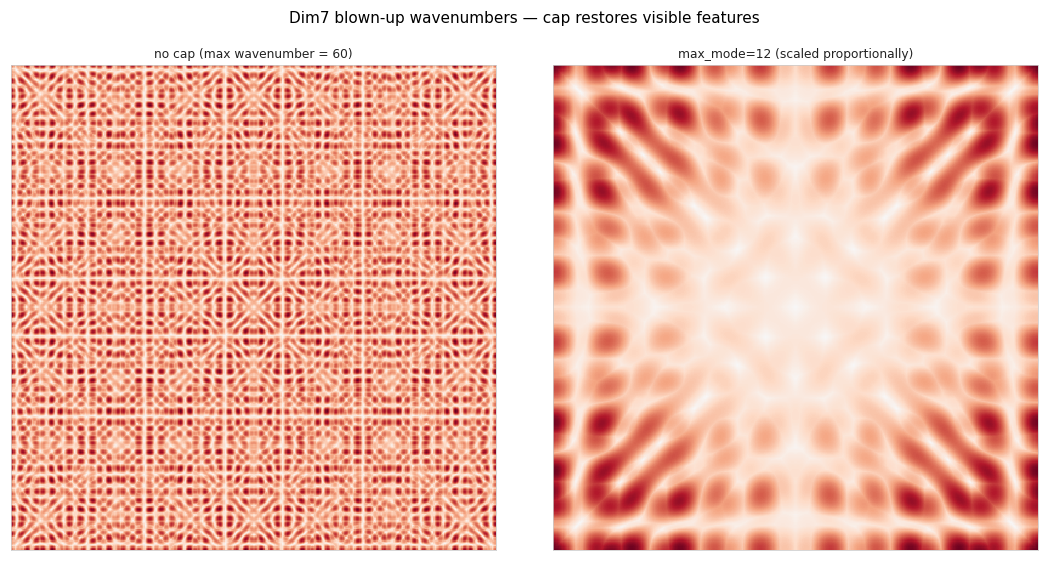

In [9]:
dim7_hi   = CHORDS_HI["Dim7"]  # Fraction form — round-trips to small ints here
dim7_high_lcm = [35, 42, 49, 60]  # the same chord re-expressed in 12-TET-flavoured form
print(f"  Dim7 (12-TET-style Fraction LCM): {dim7_high_lcm}")

plotting.gallery(
    [chladni_field_pairwise(dim7_high_lcm, antisymmetric=True, symmetry="d4_max",
                             resolution=400),  # no cap
     chladni_field_pairwise(dim7_high_lcm, antisymmetric=True, symmetry="d4_max",
                             resolution=400, max_mode=12)],
    n_cols=2,
    titles=[f"no cap (max wavenumber = {max(dim7_high_lcm)})",
            "max_mode=12 (scaled proportionally)"],
    suptitle="Dim7 blown-up wavenumbers — cap restores visible features",
    fig_width=10.0,
);


## 7. Triple-antisymmetric — chords of ≥3 ratios

The triple-antisymmetric scheme sums the cyclic chain of antisymmetric
pair-modes over every distinct triple in the chord:

$$M(a,b) + M(b,c) + M(c,a)\quad\text{for each}\;(a,b,c)\subset\text{chord}$$

where $M(p,q) = \cos(p\pi X)\cos(q\pi Y) - \cos(q\pi X)\cos(p\pi Y)$.
This emphasises **triadic** interactions — a triadic chord contributes
one rich three-fold-flavoured mode rather than three independent
pair modes.


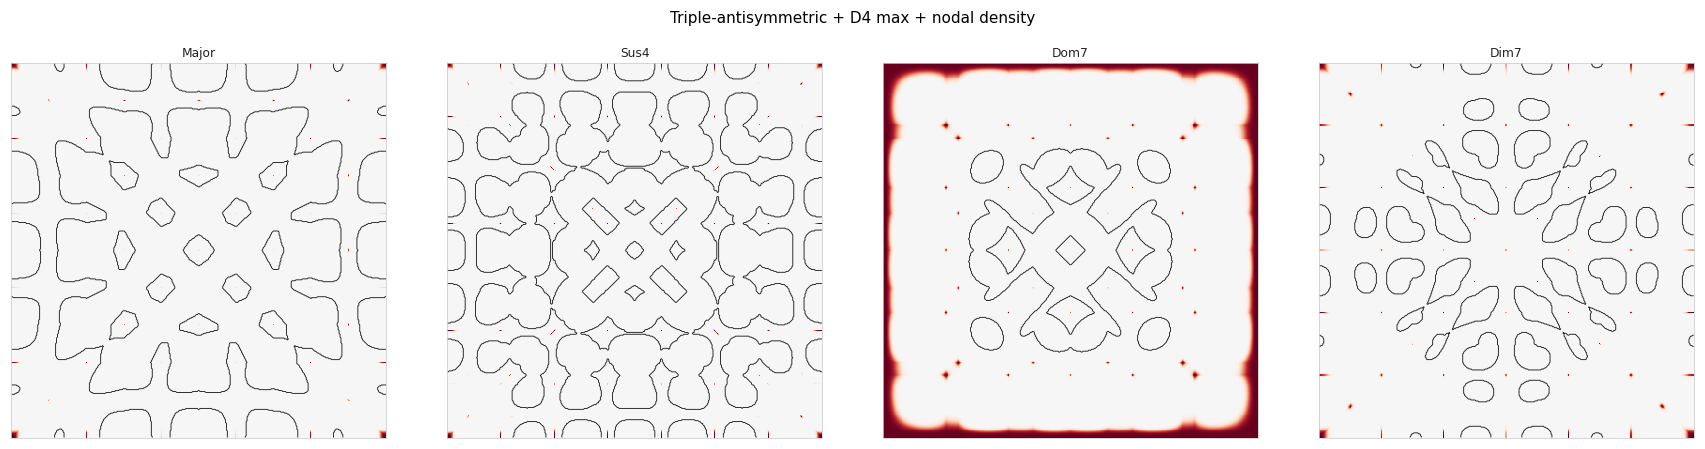

In [10]:
sigma = 0.05
geoms = [
    chladni_nodal_density(
        chladni_field_triple_antisymmetric(
            CHORDS_INT[name], symmetry="d4_max", resolution=400,
        ),
        sigma=sigma,
    )
    for name in CHORDS_INT
]
plotting.gallery(geoms, n_cols=4, titles=list(CHORDS_INT.keys()),
                 suptitle="Triple-antisymmetric + D4 max + nodal density",
                 fig_width=16.0);


## 8. Animation — chord-sequence morph

``plotting.animate_chord_sequence`` drives any chord→geometry builder
through a cosine-eased loop. Each keyframe is an integer-ratio list;
mid-segment frames receive interpolated floats (which the cymatics
builders accept — they don't have to be exact eigenmodes mid-morph).

The cell below renders a ~8-second MP4 at 24 fps × 48 frames-per-segment
through ``[Major, Sus4, "alt-Major", "alt-Sus4"]`` and back. The MP4
file is written to ``renders/`` next to the notebook — open it locally
to play.


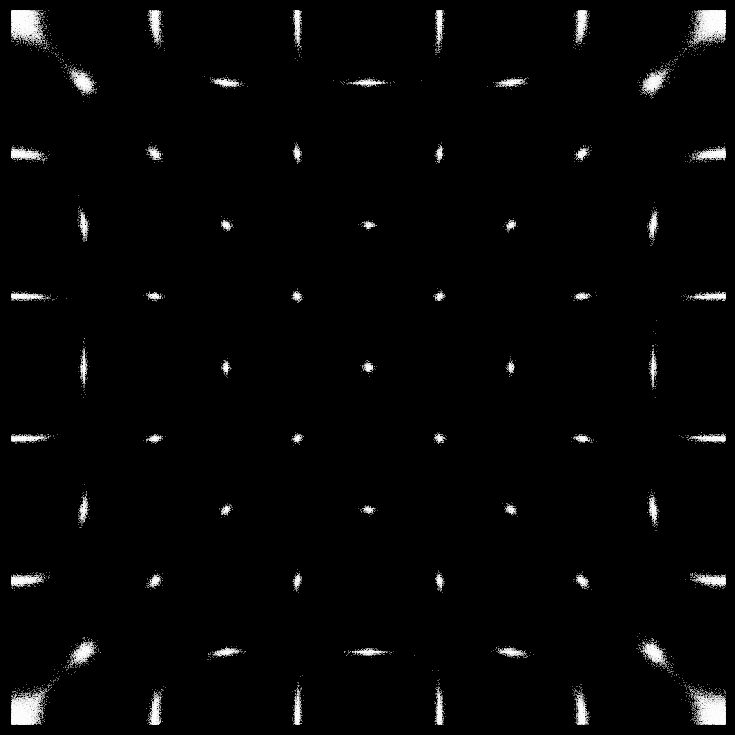

In [11]:
# All keyframes must have the same length for component-wise interpolation.
CHORD_KEYFRAMES = [
    CHORDS_INT["Major"],            # [4, 5, 6]
    CHORDS_INT["Sus4"],             # [6, 8, 9]
    [2, 3, 5],                       # demo's first chord
    [3, 4, 7],                       # demo's third chord
]
print("keyframes:", CHORD_KEYFRAMES)

def cymatics_builder(chord):
    field = chladni_field_pairwise(
        list(chord), antisymmetric=True, symmetry="d4_max", resolution=320,
    )
    return Granular(
        output_mode="particles", nodal_emphasis=True, sigma=0.06,
        n_particles=80_000, seed=0,
    ).respond(field)

os.makedirs("renders", exist_ok=True)
anim = plotting.animate_chord_sequence(
    CHORD_KEYFRAMES, cymatics_builder,
    frames_per_segment=48, fps=24, loop=True,
    figsize=(6.5, 6.5),
    point_size=0.5, point_alpha=0.45,
    save_path="renders/chladni_morph_demo.mp4",
    dpi=110,
)
print("rendered:", os.path.getsize("renders/chladni_morph_demo.mp4"), "bytes")


## Recipe quick reference

| Want | Configuration |
|---|---|
| classical Chladni (default) | `RigidPlate()` |
| iconic square-plate Chladni lattice | `chladni_field_pairwise(chord_int, antisymmetric=True, symmetry="d4_max")` |
| sand-on-the-nodes density | wrap with `chladni_nodal_density(..., sigma=0.05)` |
| sand-grain photographic look | pipe field into `Granular(output_mode="particles", nodal_emphasis=True, sigma=0.06, n_particles=180_000)` |
| triadic mode flavour | `chladni_field_triple_antisymmetric(chord_int, symmetry="d4_max")` (≥3 ratios) |
| smooth D4 averaging | `symmetry="d4_sum"` instead of `"d4_max"` |
| cap high-LCM chords | pass `max_mode=12` (or any cap) to the pairwise / triple builders |
| chord-morph MP4 | `plotting.animate_chord_sequence([chord1, chord2, ...], builder, save_path=...)` |
